Successfully read 9000 rows from h2o-abinitio.dat.
  Inferred 5 columns.

Converting columns to numeric type...

Plotting P-Rho for Temps (K): [1.2589000e+02 3.1623000e+02 1.0000000e+03 3.1622800e+03 1.0000000e+04
 3.1622780e+04 1.0000001e+05 3.1622780e+05 1.0000001e+06 3.1622781e+06]


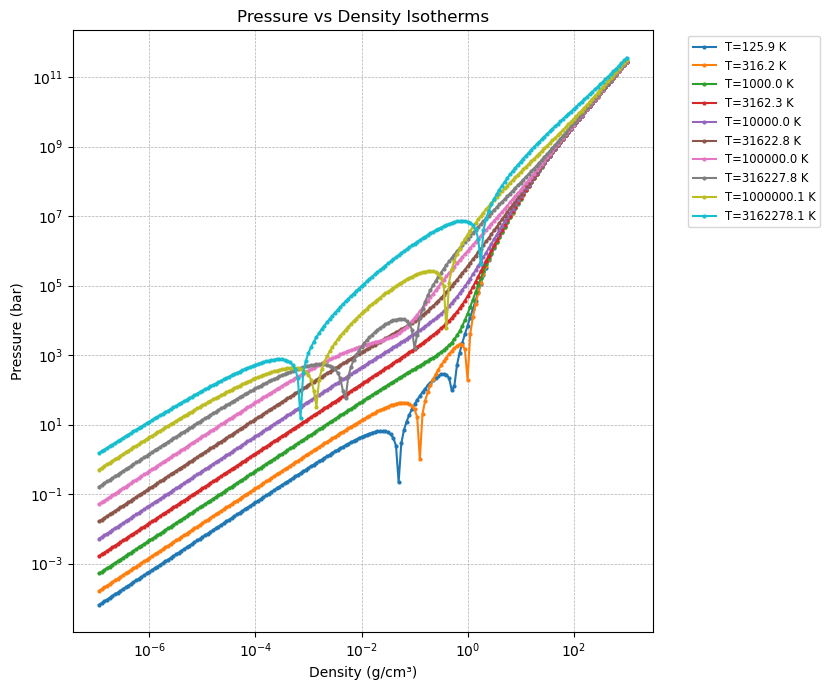


Plotting U-Rho for Temps (K): [1.2589000e+02 3.1623000e+02 1.0000000e+03 3.1622800e+03 1.0000000e+04
 3.1622780e+04 1.0000001e+05 3.1622780e+05 1.0000001e+06 3.1622781e+06]


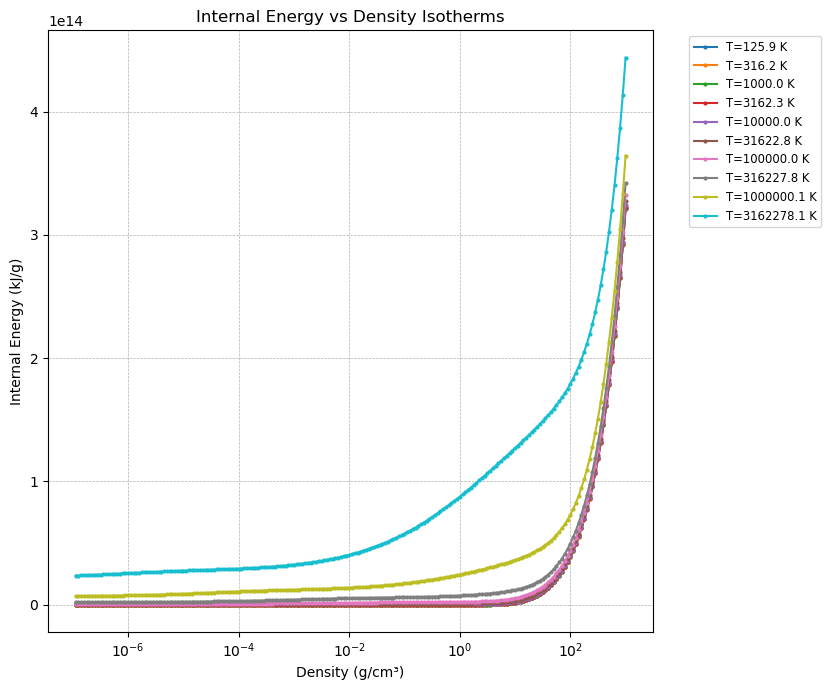


Plotting S/Other-Rho for Temps (K): [1.2589000e+02 3.1623000e+02 1.0000000e+03 3.1622800e+03 1.0000000e+04
 3.1622780e+04 1.0000001e+05 3.1622780e+05 1.0000001e+06 3.1622781e+06]


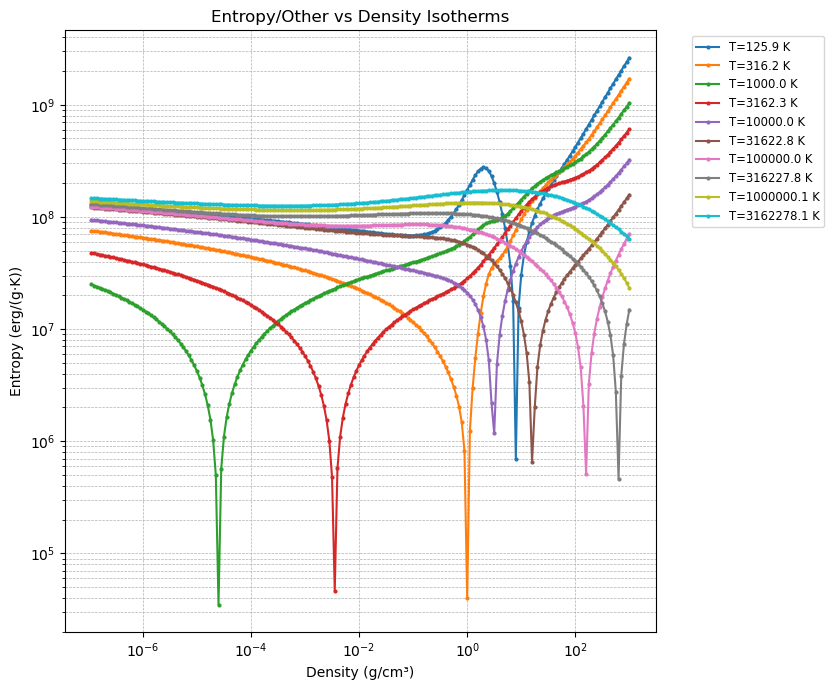

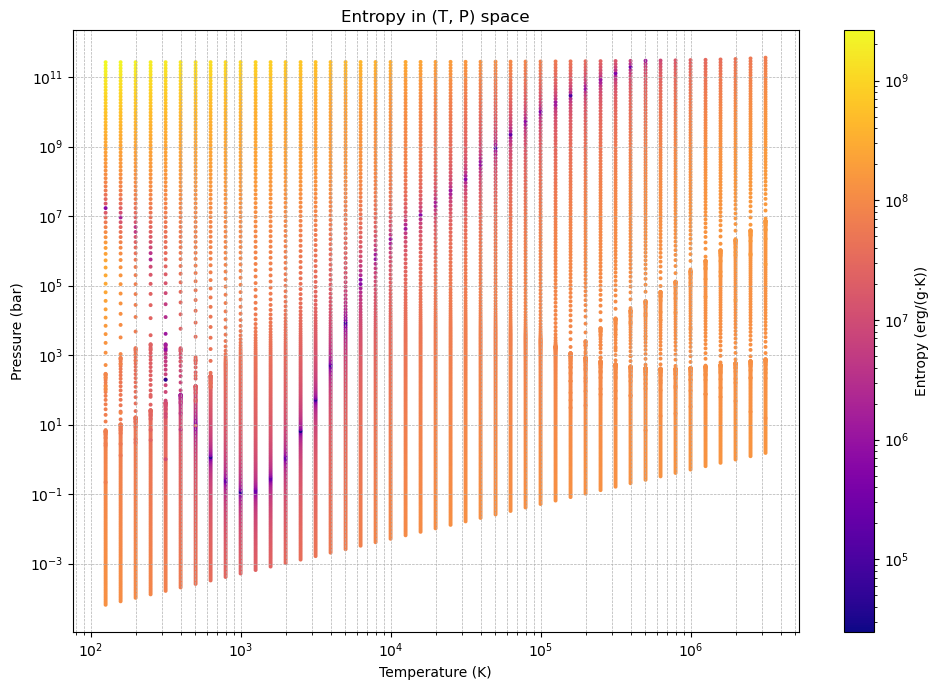

In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt

# Define the filename
filename = "h2o-abinitio.dat"

# Define NEW column names with confirmed units
column_names = ['Temperature_K', 'Density_g_cm3', 'Pressure_bar', 'InternalEnergy_kJ_g', 'Entropy_erg/(g·K)']

# --- Load the data ---
try:
    # Read the file, letting pandas INFER column widths based on whitespace
    df_eos = pd.read_fwf(filename, header=None, names=column_names, skipinitialspace=True)

    if len(df_eos.columns) != len(column_names):
         print(f"[ERROR] read_fwf inferred {len(df_eos.columns)} columns, expected {len(column_names)}.")
         exit()
    print(f"Successfully read {len(df_eos)} rows from {filename}.")
    print(f"  Inferred {len(df_eos.columns)} columns.")

    # --- Convert columns to numeric ---
    print("\nConverting columns to numeric type...")
    conversion_errors = False
    for col in column_names:
        df_eos[col] = pd.to_numeric(df_eos[col], errors='coerce')
        if df_eos[col].isnull().any():
            print(f"  [WARN] Column '{col}' contained non-numeric values (NaN).")
            conversion_errors = True

    if conversion_errors:
         print("  Please check the original data file for non-numeric entries.")

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
    exit()
except Exception as e:
    print(f"An error occurred during loading/conversion: {e}")
    exit()

# --- Updated Plotting Functions (with correct labels) ---

def plot_pressure_density_isotherms(df, num_isotherms=8):
    """Plots Pressure vs Density for a selection of isotherms."""
    plt.figure(figsize=(10, 7))
    unique_temps = df['Temperature_K'].dropna().unique()
    if len(unique_temps) > num_isotherms:
        indices = np.linspace(0, len(unique_temps) - 1, num_isotherms, dtype=int)
        temps_to_plot = unique_temps[indices]
    else:
        temps_to_plot = unique_temps
    print(f"\nPlotting P-Rho for Temps (K): {np.round(temps_to_plot, 2)}")
    plotted_count = 0
    for temp in temps_to_plot:
        isotherm_data = df[df['Temperature_K'] == temp].dropna(subset=['Density_g_cm3', 'Pressure_bar'])
        if not isotherm_data.empty:
            plt.plot(isotherm_data['Density_g_cm3'], isotherm_data['Pressure_bar'],
                     marker='.', markersize=4, linestyle='-', label=f'T={temp:.1f} K')
            plotted_count += 1
    if plotted_count > 0:
        plt.xlabel("Density (g/cm³)") # Updated label
        plt.ylabel("Pressure (bar)")   # Updated label
        plt.xscale('log')
        plt.yscale('log')
        plt.title("Pressure vs Density Isotherms")
        plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else: print("No valid data to plot for Pressure vs Density.")

def plot_energy_density_isotherms(df, num_isotherms=8):
    """Plots Internal Energy vs Density for a selection of isotherms."""
    plt.figure(figsize=(10, 7))
    unique_temps = df['Temperature_K'].dropna().unique()
    if len(unique_temps) > num_isotherms:
        indices = np.linspace(0, len(unique_temps) - 1, num_isotherms, dtype=int)
        temps_to_plot = unique_temps[indices]
    else:
        temps_to_plot = unique_temps
    print(f"\nPlotting U-Rho for Temps (K): {np.round(temps_to_plot, 2)}")
    plotted_count = 0
    for temp in temps_to_plot:
        isotherm_data = df[df['Temperature_K'] == temp].dropna(subset=['Density_g_cm3', 'Entropy_erg/(g·K)'])
        if not isotherm_data.empty:
            plt.plot(isotherm_data['Density_g_cm3'], isotherm_data['InternalEnergy_kJ_g'],
                     marker='.', markersize=4, linestyle='-', label=f'T={temp:.1f} K')
            plotted_count += 1
    if plotted_count > 0:
        plt.xlabel("Density (g/cm³)")        # Updated label
        plt.ylabel("Internal Energy (kJ/g)") # Updated label
        plt.xscale('log')
        plt.title("Internal Energy vs Density Isotherms")
        plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else: print("No valid data to plot for Energy vs Density.")

def plot_entropy_density_isotherms(df, num_isotherms=8):
    """Plots Entropy/Other vs Density for a selection of isotherms."""
    plt.figure(figsize=(10, 7))
    unique_temps = df['Temperature_K'].dropna().unique()
    if len(unique_temps) > num_isotherms:
        indices = np.linspace(0, len(unique_temps) - 1, num_isotherms, dtype=int)
        temps_to_plot = unique_temps[indices]
    else:
        temps_to_plot = unique_temps
    print(f"\nPlotting S/Other-Rho for Temps (K): {np.round(temps_to_plot, 2)}")
    plotted_count = 0
    for temp in temps_to_plot:
        isotherm_data = df[df['Temperature_K'] == temp].dropna(subset=['Density_g_cm3', 'Entropy_erg/(g·K)'])
        if not isotherm_data.empty:
            plt.plot(isotherm_data['Density_g_cm3'], isotherm_data['Entropy_erg/(g·K)'],
                     marker='.', markersize=4, linestyle='-', label=f'T={temp:.1f} K')
            plotted_count += 1
    if plotted_count > 0:
        plt.xlabel("Density (g/cm³)")       # Updated label
        plt.ylabel("Entropy (erg/(g·K))") # Keep units generic for now
        plt.xscale('log')
        plt.title("Entropy/Other vs Density Isotherms")
        plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.yscale('log')
        plt.show()
    else: print("No valid data to plot for Entropy/Other vs Density.")

def plot_entropy_in_TP_space(df, logscale=True):
    """Plots entropy as a colormap in Temperature vs Pressure space."""
    import matplotlib.colors as mcolors

    # Drop rows with NaNs in the relevant columns
    df_clean = df.dropna(subset=['Temperature_K', 'Pressure_bar', 'Entropy_erg/(g·K)'])

    T = df_clean['Temperature_K'].values
    P = df_clean['Pressure_bar'].values
    S = df_clean['Entropy_erg/(g·K)'].values

    # Set up the plot
    plt.figure(figsize=(10, 7))
    norm = mcolors.LogNorm(vmin=np.nanmin(S), vmax=np.nanmax(S)) if logscale else None

    scatter = plt.scatter(T, P, c=S, cmap='plasma', norm=norm,
                          s=8, edgecolor='none')

    plt.xlabel("Temperature (K)")
    plt.ylabel("Pressure (bar)")
    if logscale:
        plt.xscale('log')
        plt.yscale('log')
    plt.title("Entropy in (T, P) space")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Entropy (erg/(g·K))")

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()


# --- Generate Plots ---
if not df_eos.isnull().all().all() and not df_eos.empty:
    plot_pressure_density_isotherms(df_eos, num_isotherms=10)
    plot_energy_density_isotherms(df_eos, num_isotherms=10)
    plot_entropy_density_isotherms(df_eos, num_isotherms=10)
    plot_entropy_in_TP_space(df_eos, logscale=True)
else:
    print("\nSkipping plots because DataFrame is empty or all NaN.")

In [2]:
from scipy.interpolate import LinearNDInterpolator
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

def plot_entropy_in_TP_space_with_isentropes(df, num_isentropes=10, logscale=True):
    """Plots entropy as a colormap in (T, P) space, with overlaid isentropes."""
    
    # Clean the dataframe
    df_clean = df.dropna(subset=['Temperature_K', 'Pressure_bar', 'Entropy_erg/(g·K)'])
    T = df_clean['Temperature_K'].values
    P = df_clean['Pressure_bar'].values
    S = df_clean['Entropy_erg/(g·K)'].values

    # Interpolator: (logT, logP) → logS
    logT = np.log10(T)
    logP = np.log10(P)
    logS = np.log10(S)

    interp = LinearNDInterpolator(list(zip(logT, logP)), logS)

    # Create regular grid in log space
    T_vals = np.logspace(np.log10(T.min()), np.log10(T.max()), 300)
    P_vals = np.logspace(np.log10(P.min()), np.log10(P.max()), 300)
    logT_grid, logP_grid = np.meshgrid(np.log10(T_vals), np.log10(P_vals))
    logS_grid = interp(logT_grid, logP_grid)

    # Set up plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Contourf for background entropy map
    cf = ax.contourf(10**logT_grid, 10**logP_grid, 10**logS_grid,
                     levels=200, cmap='plasma', norm=mcolors.LogNorm())

    # Colorbar
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label("Entropy (erg/(g·K))")

    # Compute isentrope levels
    Smin, Smax = np.nanmin(S), np.nanmax(S)
    isentrope_levels = np.logspace(np.log10(Smin), np.log10(Smax), num_isentropes)

    # Overlay isentropes
    cs = ax.contour(10**logT_grid, 10**logP_grid, 10**logS_grid,
                    levels=isentrope_levels, colors='white', linewidths=1.2)

    ax.clabel(cs, fmt=lambda val: f"{val:.1e}", fontsize=8, colors='white')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title("Entropy Map in (T, P) Space with Isentropes")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()


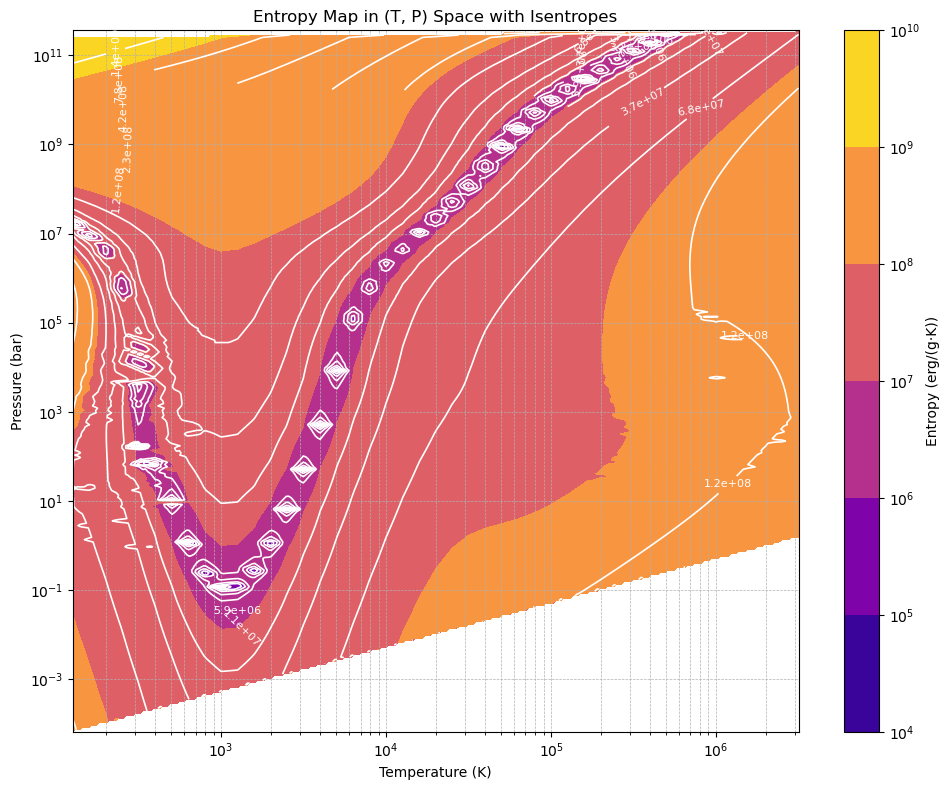

In [3]:
plot_entropy_in_TP_space_with_isentropes(df_eos, num_isentropes=20, logscale=True)


In [9]:
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_entropy_with_selected_isentrope(df, T_input, P_input, num_isentropes=10, entropy_tol=0.05):
    """
    Plots entropy in (T, P) space with isentropes, highlights selected isentrope,
    and adds red dots for entropy values close to the selected isentrope entropy.
    
    Parameters:
    - df: DataFrame with 'Temperature_K', 'Pressure_bar', 'Entropy_erg/(g·K)'
    - T_input: Input temperature (K)
    - P_input: Input pressure (bar)
    - num_isentropes: Number of isentrope contour levels
    - entropy_tol: Relative tolerance for highlighting close entropy points (fractional, e.g. 0.05 = 5%)
    """
    # --- Clean Data ---
    df_clean = df.dropna(subset=['Temperature_K', 'Pressure_bar', 'Entropy_erg/(g·K)'])
    T = df_clean['Temperature_K'].values
    P = df_clean['Pressure_bar'].values
    S = df_clean['Entropy_erg/(g·K)'].values

    # --- Find closest entropy to user point ---
    logT_input = np.log10(T_input)
    logP_input = np.log10(P_input)
    distances = np.sqrt((np.log10(T) - logT_input)**2 + (np.log10(P) - logP_input)**2)
    closest_idx = np.argmin(distances)
    S_target = S[closest_idx]
    print(f"[INFO] Closest entropy to (T={T_input}, P={P_input}) is S ≈ {S_target:.2e} erg/(g·K)")

    # --- Interpolation ---
    logT = np.log10(T)
    logP = np.log10(P)
    logS = np.log10(S)
    interp = LinearNDInterpolator(list(zip(logT, logP)), logS)

    # --- Create grid ---
    T_vals = np.logspace(np.log10(T.min()), np.log10(T.max()), 300)
    P_vals = np.logspace(np.log10(P.min()), np.log10(P.max()), 300)
    logT_grid, logP_grid = np.meshgrid(np.log10(T_vals), np.log10(P_vals))
    logS_grid = interp(logT_grid, logP_grid)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Entropy background
    cf = ax.contourf(10**logT_grid, 10**logP_grid, 10**logS_grid,
                     levels=200, cmap='plasma', norm=mcolors.LogNorm())
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label("Entropy (erg/(g·K))")

    # Isentrope contour lines
    Smin, Smax = np.nanmin(S), np.nanmax(S)
    isentrope_levels = np.logspace(np.log10(Smin), np.log10(Smax), num_isentropes)
    cs = ax.contour(10**logT_grid, 10**logP_grid, 10**logS_grid,
                    levels=np.log10(isentrope_levels), colors='white', linewidths=1)
    ax.clabel(cs, fmt=lambda val: f"{10**val:.1e}", fontsize=7, colors='white')

    # --- Highlight selected isentrope ---
    selected_contour = ax.contour(10**logT_grid, 10**logP_grid, 10**logS_grid,
                                  levels=[np.log10(S_target)], colors='cyan', linewidths=2.5, linestyles='--')
    ax.clabel(selected_contour, fmt=lambda val: f"S ≈ {10**val:.1e}", fontsize=10, colors='cyan')

    # --- Extract (T, P) along selected isentrope contour ---
    # Directly get the paths from the QuadContourSet (the attribute is 'allsegs')
    for segments in selected_contour.allsegs:
        for seg in segments:
            T_line, P_line = seg[:, 0], seg[:, 1]
            ax.plot(T_line, P_line, color='cyan', linestyle='--', linewidth=2.5, label="Selected Isentrope")


    # Input point
    ax.plot(T_input, P_input, 'o', color='black', markersize=8, label='Input (T, P)')

    # --- Add red dots for entropy points close to S_target ---
    close_mask = np.abs(S - S_target) / S_target < entropy_tol
    ax.plot(T[close_mask], P[close_mask], 'o', color='red', markersize=6, label='Close Entropy Points')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title("Entropy in (T, P) Space with Highlighted Isentrope")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return T[close_mask], P[close_mask]


[INFO] Closest entropy to (T=300, P=1) is S ≈ 1.04e+07 erg/(g·K)


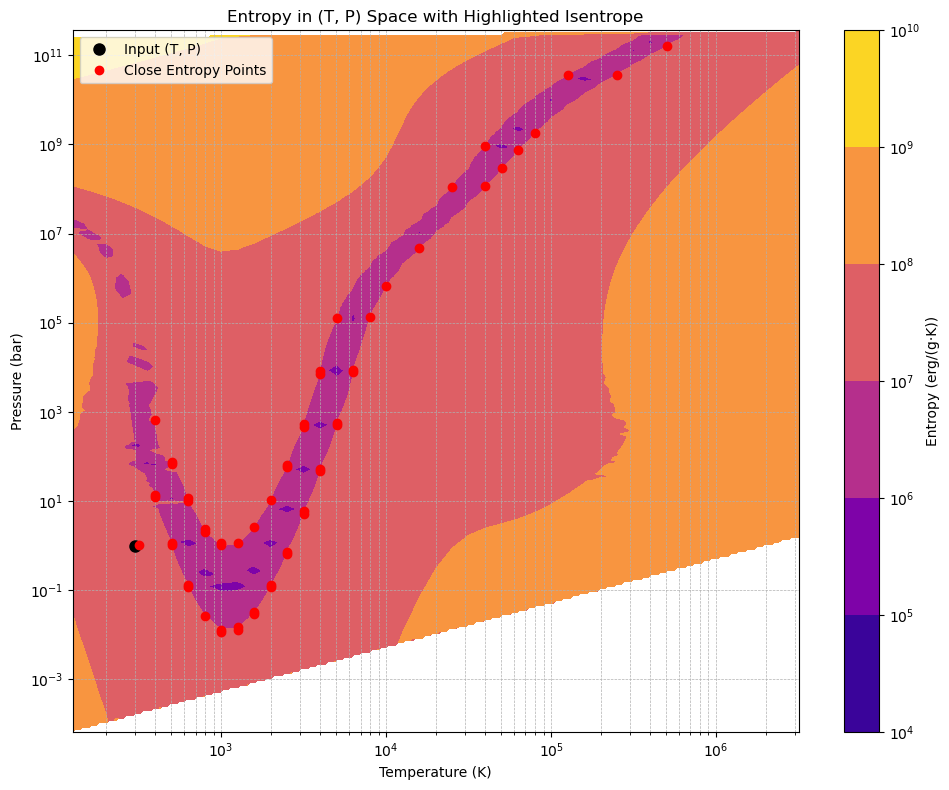

(array([3.1622777e+02, 3.9810718e+02, 3.9810718e+02, 3.9810718e+02,
        5.0118725e+02, 5.0118725e+02, 5.0118725e+02, 5.0118725e+02,
        6.3095736e+02, 6.3095736e+02, 6.3095736e+02, 6.3095736e+02,
        7.9432826e+02, 7.9432826e+02, 7.9432826e+02, 1.0000000e+03,
        1.0000000e+03, 1.0000000e+03, 1.0000000e+03, 1.2589255e+03,
        1.2589255e+03, 1.2589255e+03, 1.5848933e+03, 1.5848933e+03,
        1.5848933e+03, 1.9952624e+03, 1.9952624e+03, 1.9952624e+03,
        2.5118866e+03, 2.5118866e+03, 2.5118866e+03, 2.5118866e+03,
        3.1622778e+03, 3.1622778e+03, 3.1622778e+03, 3.1622778e+03,
        3.9810719e+03, 3.9810719e+03, 3.9810719e+03, 3.9810719e+03,
        5.0118726e+03, 5.0118726e+03, 5.0118726e+03, 6.3095738e+03,
        6.3095738e+03, 7.9432829e+03, 1.0000001e+04, 1.5848933e+04,
        2.5118866e+04, 3.9810721e+04, 3.9810721e+04, 5.0118728e+04,
        6.3095741e+04, 7.9432831e+04, 1.2589255e+05, 2.5118867e+05,
        5.0118730e+05]),
 array([1.0070148e+00, 

In [10]:
# Example call:
plot_entropy_with_selected_isentrope(df_eos, T_input=300, P_input=1, num_isentropes=10)



In [6]:
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_entropy_in_rho_P_space(df, T_input, P_input, num_isentropes=10, entropy_tol=1e-1):
    """
    Plot entropy in (density, pressure) space with isentropes, highlight selected isentrope from (T_input, P_input),
    and add red dots for points with entropy close to selected entropy.
    """

    # Clean data
    df_clean = df.dropna(subset=['Density_g_cm3', 'Pressure_bar', 'Temperature_K', 'Entropy_erg/(g·K)'])
    rho = df_clean['Density_g_cm3'].values
    P = df_clean['Pressure_bar'].values
    T = df_clean['Temperature_K'].values
    S = df_clean['Entropy_erg/(g·K)'].values

    # Find closest entropy point to input (T_input, P_input)
    logT_input = np.log10(T_input)
    logP_input = np.log10(P_input)
    distances = np.sqrt((np.log10(T) - logT_input)**2 + (np.log10(P) - logP_input)**2)
    closest_idx = np.argmin(distances)
    S_target = S[closest_idx]
    rho_input = rho[closest_idx]

    print(f"[INFO] Closest entropy to (T={T_input}, P={P_input}) is S ≈ {S_target:.2e} erg/(g·K) at density {rho_input:.3f} g/cm³")

    # Interpolate entropy in (rho, P) space, both log-scaled
    log_rho = np.log10(rho)
    log_P = np.log10(P)
    log_S = np.log10(S)
    interp = LinearNDInterpolator(list(zip(log_rho, log_P)), log_S)

    # Create grid
    rho_vals = np.logspace(np.log10(rho.min()), np.log10(rho.max()), 300)
    P_vals = np.logspace(np.log10(P.min()), np.log10(P.max()), 300)
    log_rho_grid, log_P_grid = np.meshgrid(np.log10(rho_vals), np.log10(P_vals))
    log_S_grid = interp(log_rho_grid, log_P_grid)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Entropy background
    cf = ax.contourf(10**log_rho_grid, 10**log_P_grid, 10**log_S_grid,
                     levels=200, cmap='plasma', norm=mcolors.LogNorm())
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label("Entropy (erg/(g·K))")

    # Isentrope contour lines
    Smin, Smax = np.nanmin(S), np.nanmax(S)
    isentrope_levels = np.logspace(np.log10(Smin), np.log10(Smax), num_isentropes)
    cs = ax.contour(10**log_rho_grid, 10**log_P_grid, 10**log_S_grid,
                    levels=np.log10(isentrope_levels), colors='white', linewidths=1)
    ax.clabel(cs, fmt=lambda val: f"{10**val:.1e}", fontsize=7, colors='white')

    # Highlight selected isentrope
    selected_contour = ax.contour(10**log_rho_grid, 10**log_P_grid, 10**log_S_grid,
                                  levels=[np.log10(S_target)], colors='cyan', linewidths=2.5, linestyles='--')
    ax.clabel(selected_contour, fmt=lambda val: f"S ≈ {10**val:.1e}", fontsize=10, colors='cyan')

    # Plot selected isentrope line
    for segments in selected_contour.allsegs:
        for seg in segments:
            rho_line, P_line = seg[:, 0], seg[:, 1]
            ax.plot(rho_line, P_line, color='cyan', linestyle='--', linewidth=2.5, label="Selected Isentrope")

    # Plot input point (converted to rho-P)
    ax.plot(rho_input, P_input, 'o', color='black', markersize=8, label='Input (T,P) → (ρ,P)')

    # Add red dots for points close in entropy to S_target (within relative tolerance)
    relative_diff = np.abs(S - S_target) / S_target
    close_points = relative_diff < entropy_tol
    ax.scatter(rho[close_points], P[close_points], color='red', s=20, label=f'Entropy close to S ≈ {S_target:.1e}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Density (g/cm³)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title("Entropy in (Density, Pressure) Space with Highlighted Isentrope")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()


[INFO] Closest entropy to (T=300, P=1) is S ≈ 1.04e+07 erg/(g·K) at density 0.126 g/cm³


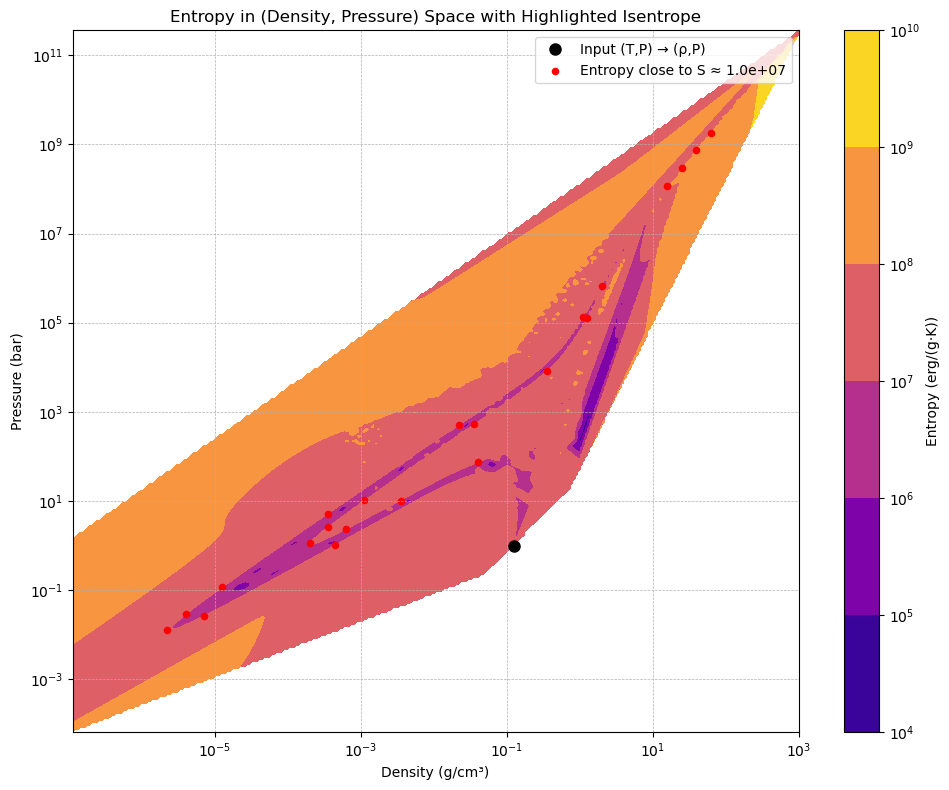

In [7]:
plot_entropy_in_rho_P_space(df_eos, T_input=300, P_input=1, num_isentropes=10, entropy_tol=0.02)


In [11]:
def integrate_isentrope(EOS_df, T0, P0, logP_step=0.01, n_steps=100, S_tol=1e-3, plot=False):
    """
    Numerically integrate an isentrope from a starting (T0, P0) using the EOS data.
    EOS_df must contain columns: 'logT', 'logP', 'rho', 'S', 'u'
    """
    import numpy as np
    import matplotlib.pyplot as plt

    logP_vals = EOS_df['logP'].values
    logT_vals = EOS_df['logT'].values
    S_vals = EOS_df['S'].values
    rho_vals = EOS_df['rho'].values
    u_vals = EOS_df['u'].values

    # Get initial entropy
    logP0 = np.log10(P0)
    logT0 = np.log10(T0)
    start_idx = np.argmin((logP_vals - logP0)**2 + (logT_vals - logT0)**2)
    S0 = S_vals[start_idx]

    logP_range = np.linspace(logP0 - logP_step * n_steps, logP0 + logP_step * n_steps, 2 * n_steps + 1)
    isentrope_T = []
    isentrope_P = []
    isentrope_rho = []
    isentrope_u = []

    for lp in logP_range:
        # Filter EOS near logP=lp
        mask = np.abs(logP_vals - lp) < logP_step
        if not np.any(mask): continue
        S_slice = S_vals[mask]
        delta_S = np.abs(S_slice - S0)
        min_idx = np.argmin(delta_S)
        if delta_S[min_idx] > S_tol:
            continue  # skip if too far in entropy

        # Save corresponding T, rho, u
        isentrope_T.append(10**logT_vals[mask][min_idx])
        isentrope_P.append(10**logP_vals[mask][min_idx])
        isentrope_rho.append(rho_vals[mask][min_idx])
        isentrope_u.append(u_vals[mask][min_idx])

    if plot:
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(isentrope_P, isentrope_T, 'o-', label='Isentrope')
        axs[0].set_xscale('log')
        axs[0].set_xlabel('Pressure (bar)')
        axs[0].set_ylabel('Temperature (K)')
        axs[0].set_title('T–P Isentrope')

        axs[1].plot(isentrope_P, isentrope_rho, 'o-', label='Isentrope')
        axs[1].set_xscale('log')
        axs[1].set_yscale('log')
        axs[1].set_xlabel('Pressure (bar)')
        axs[1].set_ylabel('Density (g/cm³)')
        axs[1].set_title('ρ–P Isentrope')

        axs[2].plot(isentrope_P, isentrope_u, 'o-', label='Isentrope')
        axs[2].set_xscale('log')
        axs[2].set_xlabel('Pressure (bar)')
        axs[2].set_ylabel('Internal Energy')
        axs[2].set_title('u–P Isentrope')

        plt.tight_layout()
        plt.show()

    return {
        'T': np.array(isentrope_T),
        'P': np.array(isentrope_P),
        'rho': np.array(isentrope_rho),
        'u': np.array(isentrope_u),
        'S': S0
    }


In [ ]:
integrate_isentrope(EOS_df, T0, P0, logP_step=0.01, n_steps=100, S_tol=1e-3, plot=True)